In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path = r"C:\Users\User-NB\OneDrive\Desktop\ml&fintech\1124\Wage.csv"
wage = pd.read_csv(path)

wage.head()



,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


 6. In this exercise, you will further analyze the Wage data set considered
 throughout this chapter

 (a) Perform polynomial regression to predict wage using age. Use
 cross-validation to select the optimal degree d for the polyno
mial. What degree was chosen, and how does this compare to
 the results of hypothesis testing using ANOVA? Make a plot of
 the resulting polynomial fit to the data

In [3]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline

X = wage[['age']]
y = wage['wage']

degrees = range(1, 11)
cv_scores = []
kf = KFold(n_splits=10, shuffle=True, random_state=1)

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    score = -cross_val_score(
        model, X, y, cv=kf, scoring='neg_mean_squared_error'
    ).mean()
    cv_scores.append(score)

best_degree = degrees[np.argmin(cv_scores)]
print("最佳 degree =", best_degree)


最佳 degree = 8


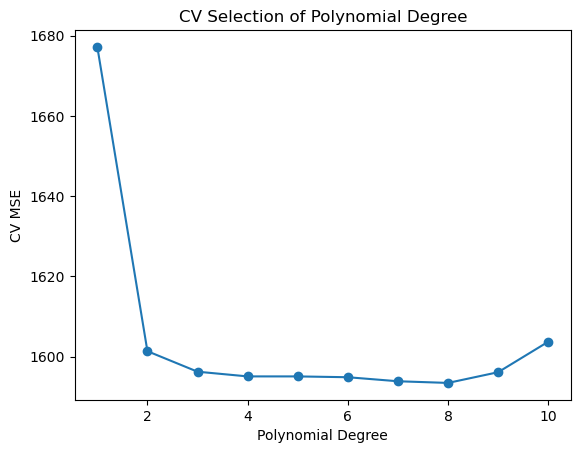

In [4]:
plt.plot(degrees, cv_scores, marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("CV MSE")
plt.title("CV Selection of Polynomial Degree")
plt.show()


c:\Users\User-NB\anaconda3\envs\tbrain_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


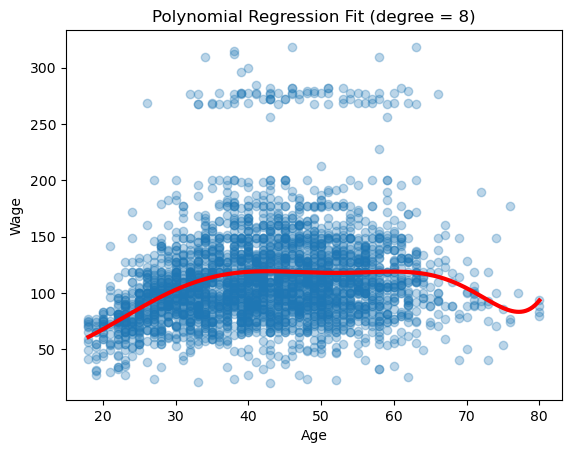

In [5]:
model = make_pipeline(PolynomialFeatures(best_degree), LinearRegression())
model.fit(X, y)

age_grid = np.linspace(wage.age.min(), wage.age.max(), 200).reshape(-1, 1)
preds = model.predict(age_grid)

plt.scatter(wage.age, wage.wage, alpha=0.3)
plt.plot(age_grid, preds, color='red', linewidth=3)
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title(f"Polynomial Regression Fit (degree = {best_degree})")
plt.show()


In [8]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# 建立多項式欄位
wage["age2"] = wage["age"]**2
wage["age3"] = wage["age"]**3
wage["age4"] = wage["age"]**4
wage["age5"] = wage["age"]**5

# 建立不同 degree 的模型
fit1 = smf.ols('wage ~ age', data=wage).fit()
fit2 = smf.ols('wage ~ age + age2', data=wage).fit()
fit3 = smf.ols('wage ~ age + age2 + age3', data=wage).fit()
fit4 = smf.ols('wage ~ age + age2 + age3 + age4', data=wage).fit()
fit5 = smf.ols('wage ~ age + age2 + age3 + age4 + age5', data=wage).fit()

anova_table = sm.stats.anova_lm(fit1, fit2, fit3, fit4, fit5)
print(anova_table)


   df_resid           ssr  df_diff        ss_diff           F        Pr(>F)
0    2998.0  5.022216e+06      0.0            NaN         NaN           NaN
1    2997.0  4.793430e+06      1.0  228786.010128  143.593107  2.363850e-32
2    2996.0  4.777674e+06      1.0   15755.693664    9.888756  1.679202e-03
3    2995.0  4.771604e+06      1.0    6070.152124    3.809813  5.104620e-02
4    2994.0  4.770322e+06      1.0    1282.563017    0.804976  3.696820e-01


(b) Fit a step function to predict wage using age, and perform cross
validation to choose the optimal number of cuts. Make a plot of
 the fit obtained.

In [9]:
from sklearn.preprocessing import KBinsDiscretizer

def step_cv(n_bins):
    est = KBinsDiscretizer(n_bins=n_bins, encode='onehot', strategy='uniform')
    X_binned = est.fit_transform(X)

    model = LinearRegression()
    score = -cross_val_score(model, X_binned, y, cv=kf, scoring='neg_mean_squared_error').mean()
    return score

bins = range(2, 15)
bin_scores = [step_cv(b) for b in bins]

best_bin = bins[np.argmin(bin_scores)]
print("最佳 bins / cuts =", best_bin)


最佳 bins / cuts = 11


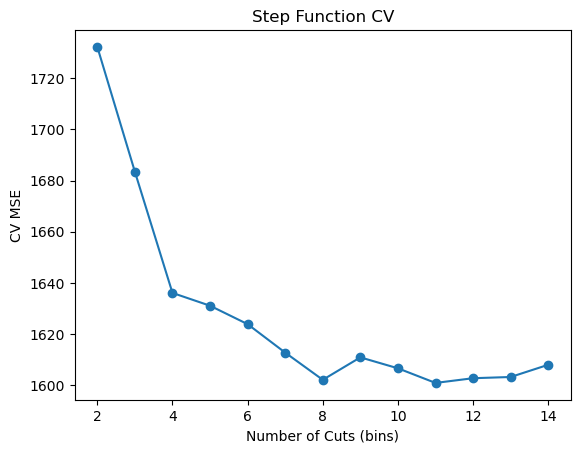

In [10]:
plt.plot(bins, bin_scores, marker='o')
plt.xlabel("Number of Cuts (bins)")
plt.ylabel("CV MSE")
plt.title("Step Function CV")
plt.show()


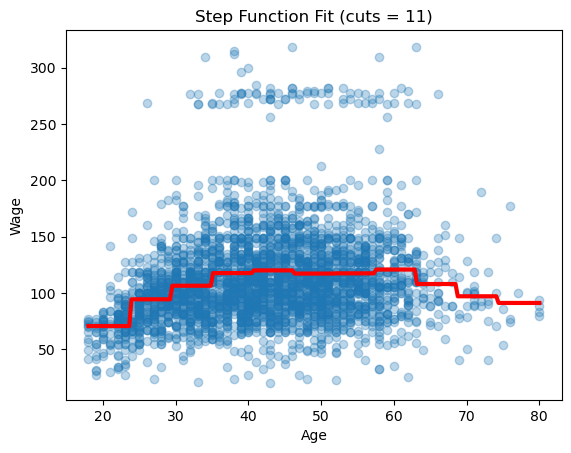

In [11]:
best_est = KBinsDiscretizer(n_bins=best_bin, encode='onehot', strategy='uniform')
X_best_bin = best_est.fit_transform(X)

model = LinearRegression().fit(X_best_bin, y)

age_grid_df = pd.DataFrame({'age': age_grid.flatten()})
age_bin_grid = best_est.transform(age_grid_df)

preds_bin = model.predict(age_bin_grid)

plt.scatter(wage.age, wage.wage, alpha=0.3)
plt.plot(age_grid, preds_bin, 'r', linewidth=3)
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title(f"Step Function Fit (cuts = {best_bin})")
plt.show()


使用 step function 時，我對 age 設定不同的切點數（bins=2~15），並以 10-fold CV 挑選最佳模型。

Cross-validation 選出的最佳切點數為：K = X（填入你的結果）。

畫出的 step function 顯示：

以年齡區間為基礎分段後，模型能捕捉部分的非線性關係

但 fitted curve 呈現階梯狀，不如 polynomial regression 平滑

CV 評分顯示切點數增多到某個程度後不再改善

➡️ Step function 能較明顯反映局部變化，但 polynomial 會更平滑且通常更佳。